## Metrics and Evaluation - Heart Disease Prediction Dataset

In this notebook, the user will develop a classification model designed to predict the presence of heart disease in patients based on clinical parameters. The primary objective is to evaluate the model’s performance using a variety of classification metrics and validation techniques to ensure diagnostic reliability.

The dataset is sourced from [Kaggle](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset) and contains several medical predictor variables, such as age, cholesterol levels, and maximum heart rate achieved.

### Project Workflow

* **Data Acquisition:** Download and preprocess the `heartdisease.csv` dataset.
* **Model Training:** Implement a supervised learning algorithm to classify patients as either "Positive" or "Negative" for heart disease.
* **Performance Analysis:** Assess accuracy, precision, recall, and F1-score.
* **Export:** The final model will be exported into ONNX, even if the final program is still on Python.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, FunctionTransformer
from sklearn.compose import ColumnTransformer

In [3]:
# The `path` variable points to the directory of the downloaded files.
# We are interested in the `bank.csv` file specifically.
filepath = "heart.csv"

data = pd.read_csv(filepath)

data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## EDA

Let's start by exploring the dataset and understanding the features and target variable.
Here is the list of all features in the dataset:

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### Target variable analysis

Our target variable is `heartDiseasse`, which indicates whether they are sick or not.

Text(0.5, 1.0, "Distribution of target variable 'HeartDisease'")

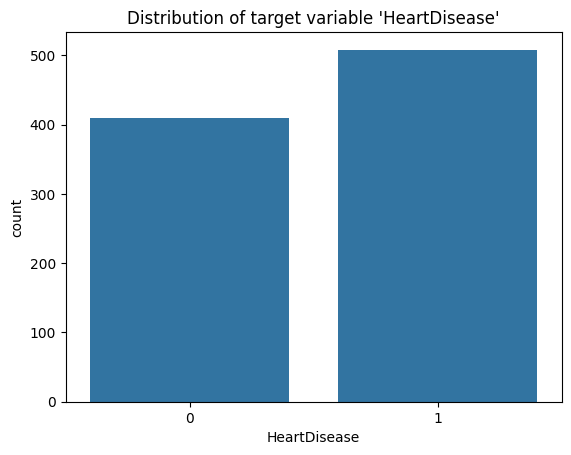

In [5]:
sns.countplot(data=data, x="HeartDisease")
plt.title("Distribution of target variable 'HeartDisease'")

### Feature analysis

Let's start by understanding the descriptive statistics of the dataset.

In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


We can also visualize the distribution of numerical features.

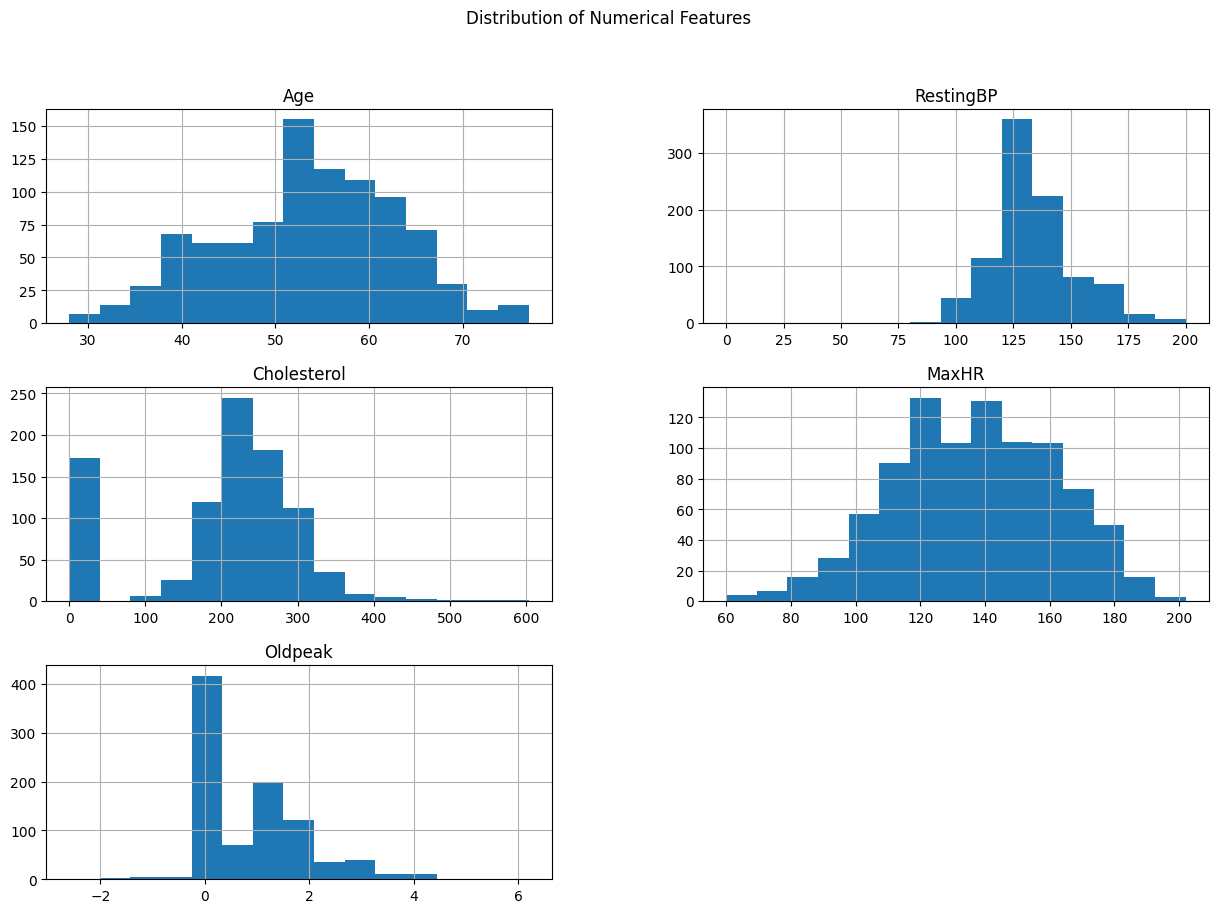

In [7]:
numerical_features = [    'Age',
    'RestingBP',
    'Cholesterol',
    'MaxHR',
    'Oldpeak']

data[numerical_features].hist(bins=15, figsize=(15, 10))
plt.suptitle("Distribution of Numerical Features")
plt.show()

Let's also look at the distribution of categorical features. Note that we are considering day and month as categorical features for this analysis, since they have a limited number of unique values.

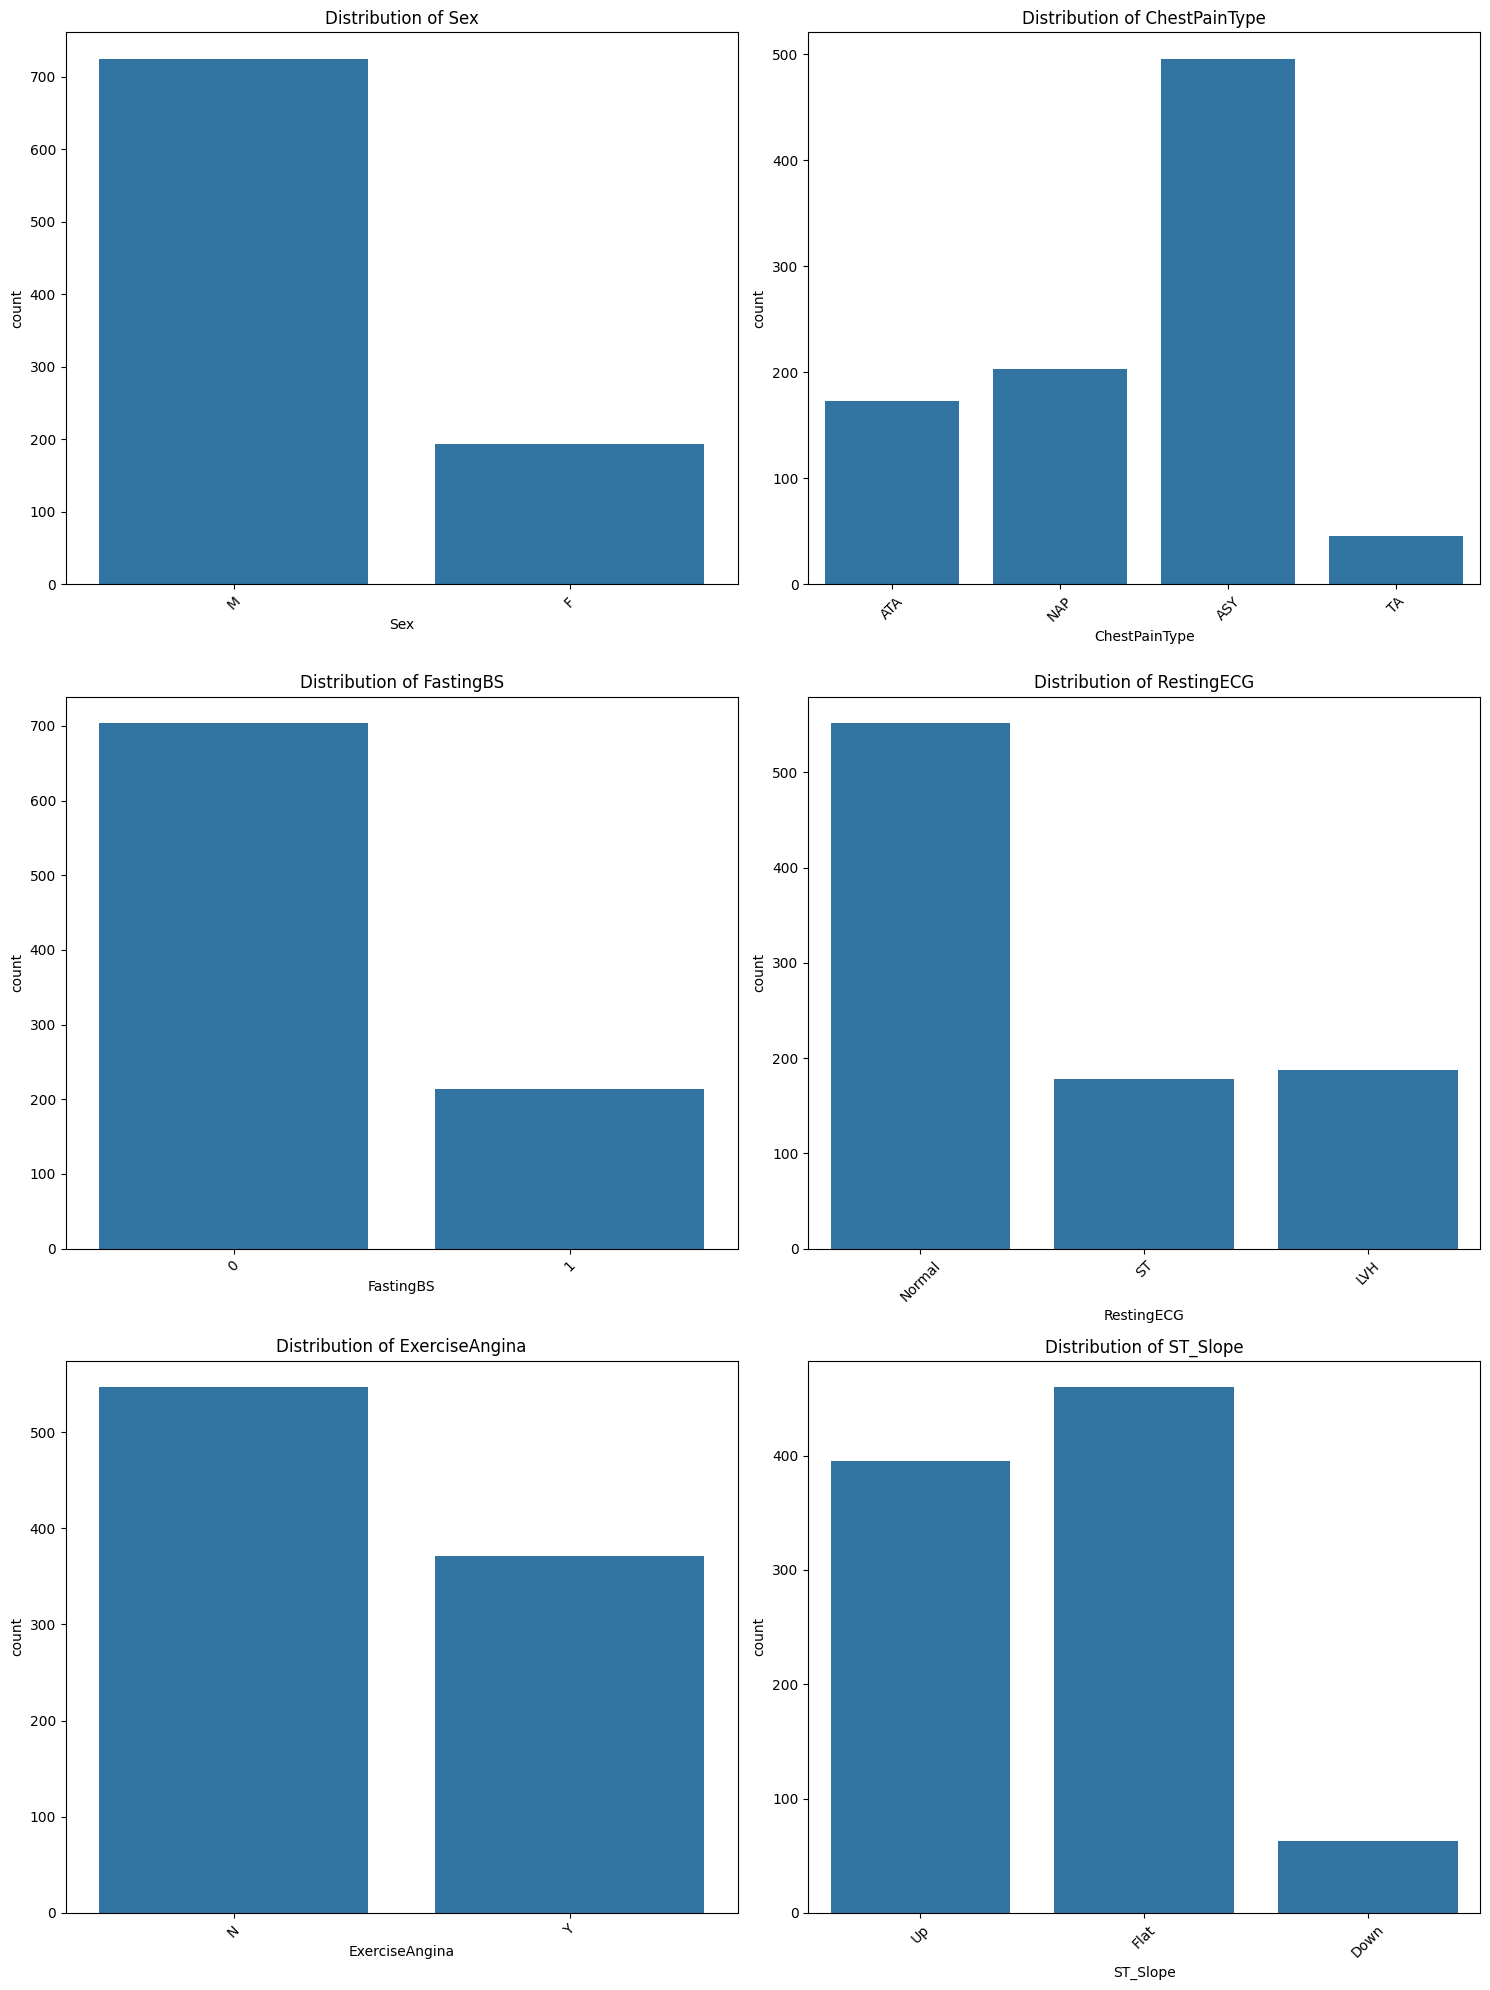

In [21]:
categorical_features = [  'Sex',
    'ChestPainType',
    'FastingBS',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 20))

for ax, feature in zip(axes.ravel(), categorical_features):
    sns.countplot(data=data, x=feature, ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()

### Data Exploration and Feature Analysis

The heart disease dataset comprises a mix of clinical and demographic variables. To prepare the data for classification, the features are categorized into two primary groups:

* **Categorical Features:** `Sex`, `ChestPainType`, `FastingBS`, `RestingECG`, `ExerciseAngina`, and `ST_Slope`.
* **Numerical Features:** `Age`, `RestingBP`, `Cholesterol`, `MaxHR`, and `Oldpeak`.

The following section investigates the integrity of the data by assessing the proportion of missing or placeholder values. Unlike the bank marketing dataset, this heart disease dataset is generally noted for its completeness.


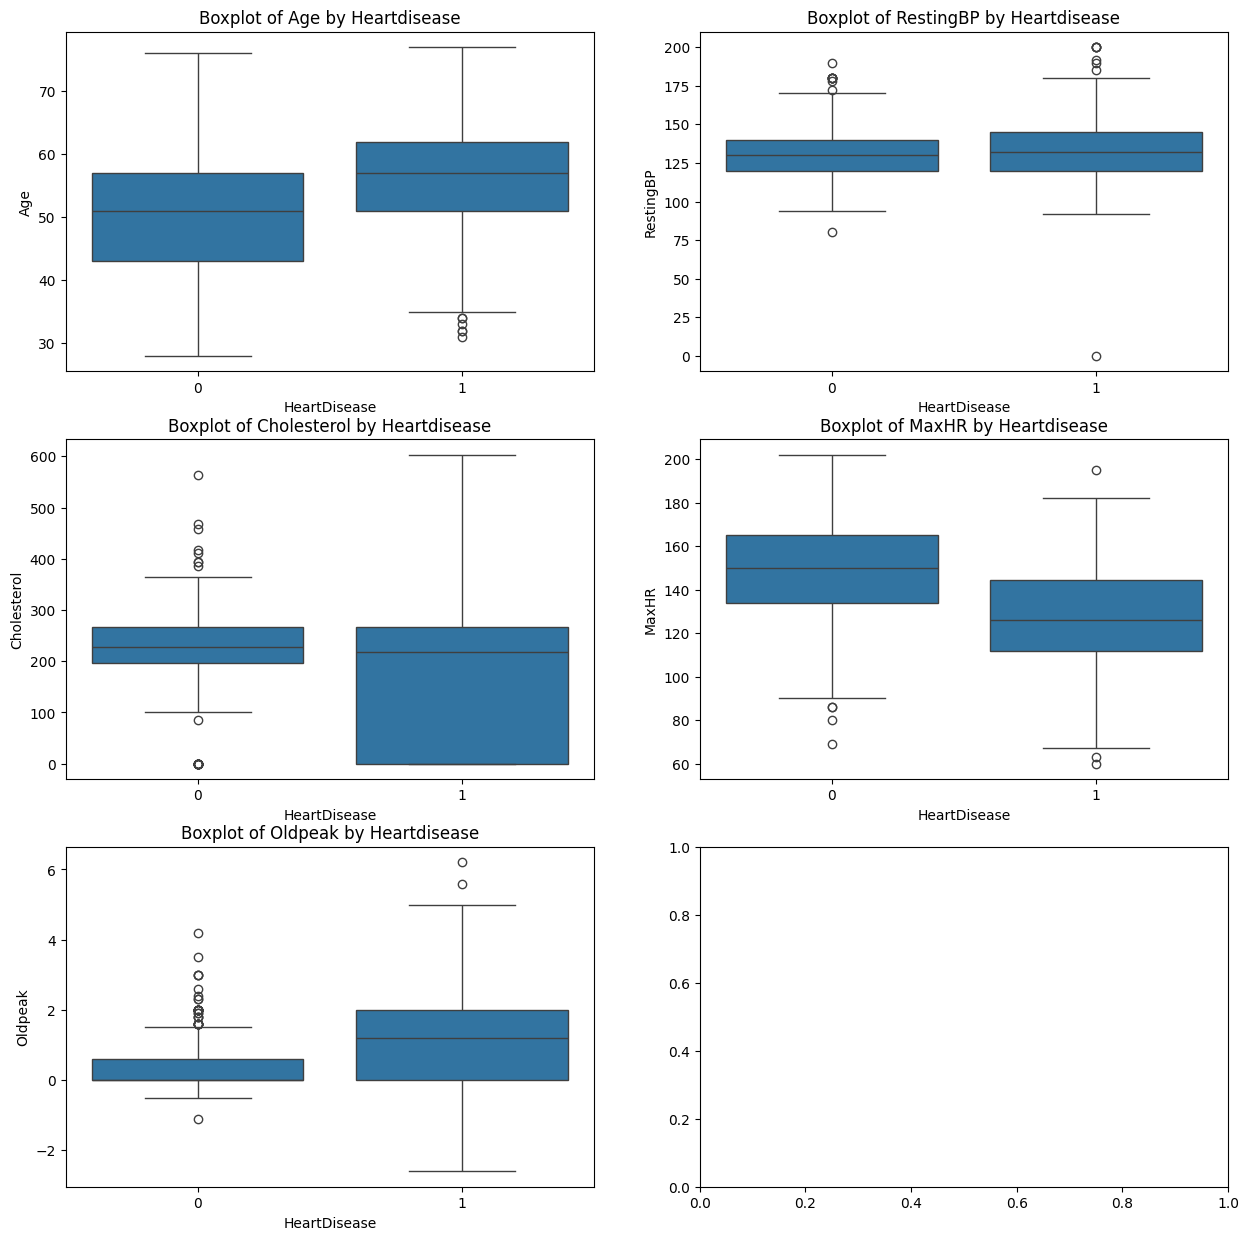

In [9]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))

for ax, feature in zip(axes.ravel(), numerical_features):
    sns.boxplot(data=data, x="HeartDisease", y=feature, ax=ax)
    ax.set_title(f"Boxplot of {feature} by Heartdisease")

We can also use countplots to visualize the relationship between categorical features and the target variable.

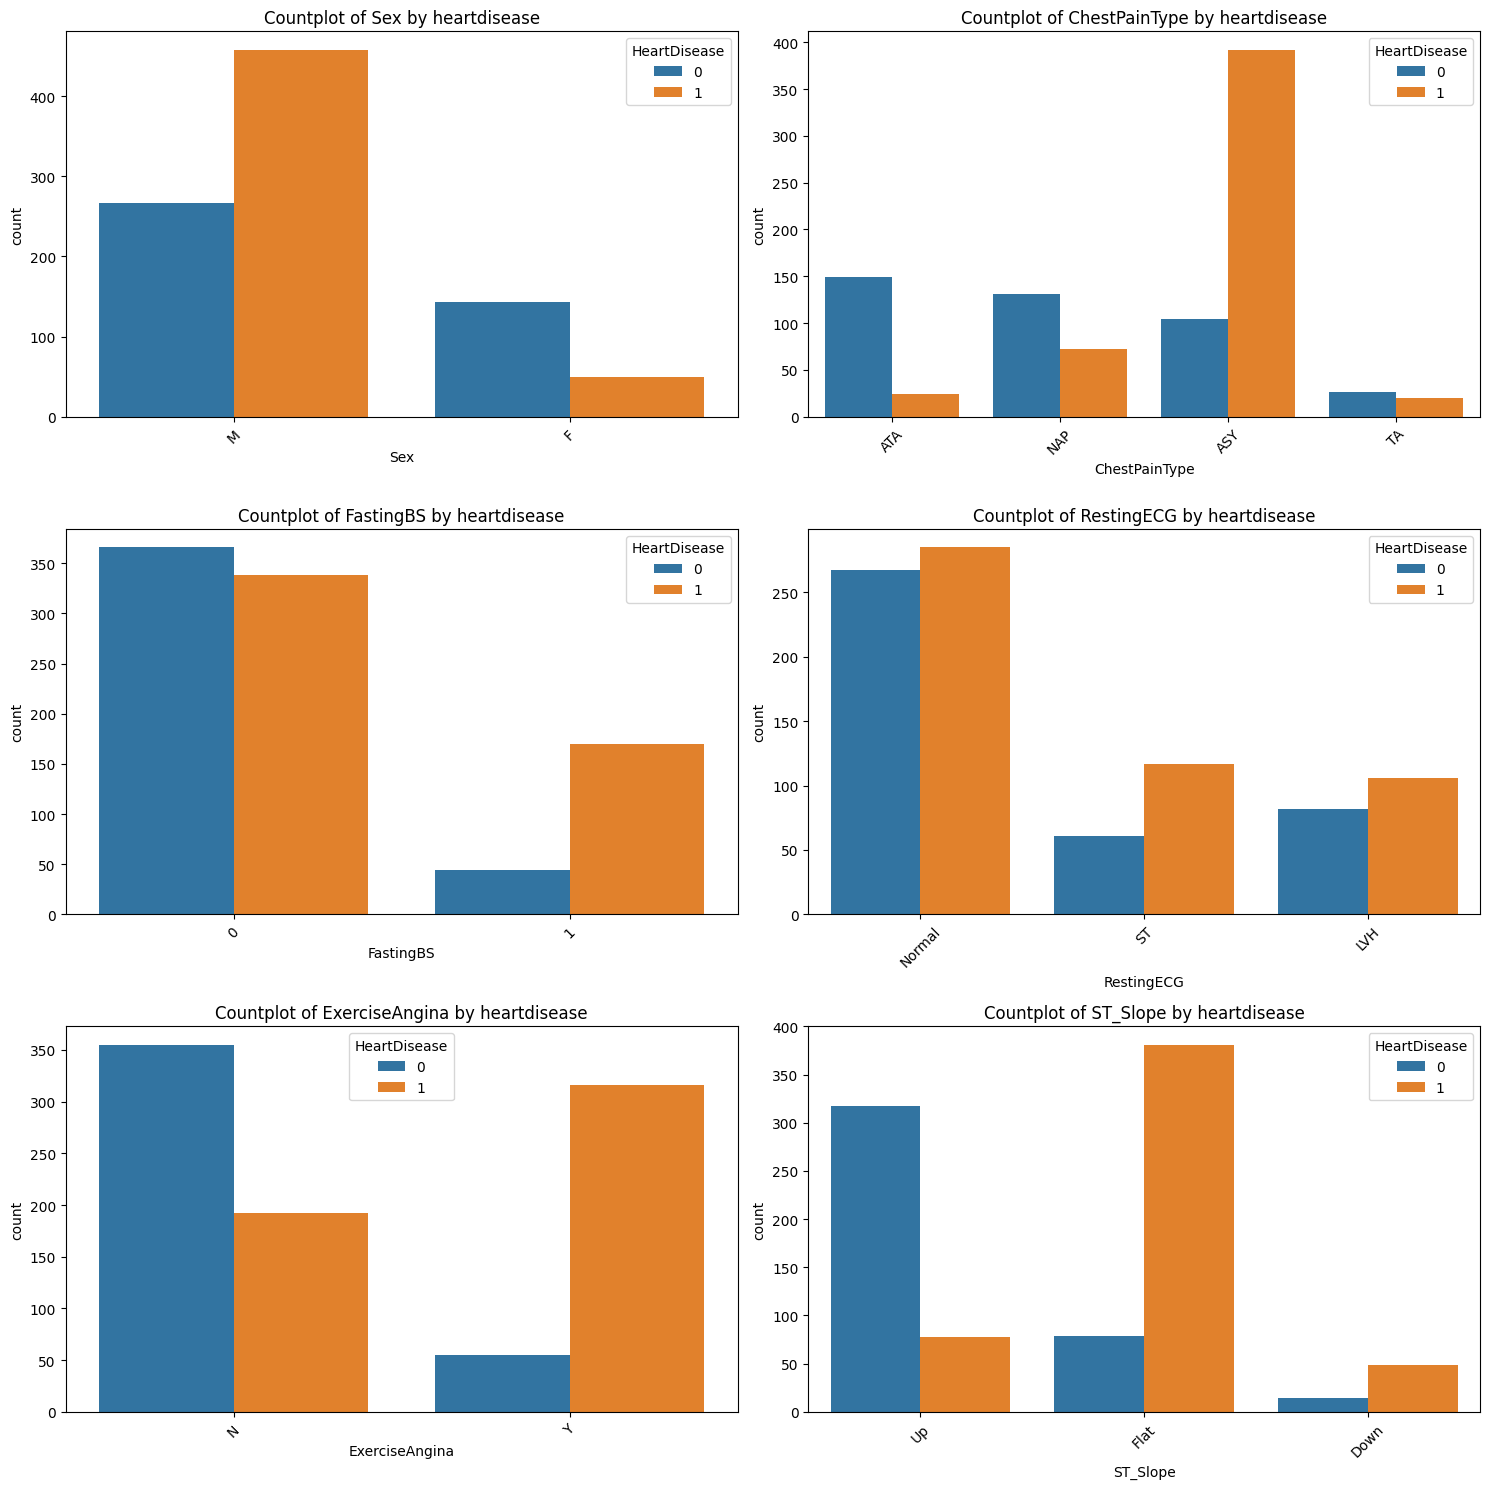

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))

for ax, feature in zip(axes.ravel(), categorical_features):
    sns.countplot(data=data, x=feature, hue="HeartDisease", ax=ax)
    ax.set_title(f"Countplot of {feature} by heartdisease")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Data conclusions

1. We can observe on the graph that there is a higher occurence of heart disease among male patients, even if there are more male than female patients, the proportion is clearly higher.

2. Patients who experience ExerciseAngina are more likely to be classified as having heart disease.

3. We can also see that the ST_SLOPE by heartdisease, there is a clear relation between Flat and heartdisease, where the column with heart disease is the biggest on its section.

4. If their chestpain type is ASY, it is almost guaranteed that they have heart disease.



## Data preprocessing

Now that we have some understanding of the dataset, we can start with data preprocessing. The first step is to separate the features and the target variable. We will not drop any feature, there are no empty values.

In [11]:
data['FastingBS'] = data['FastingBS'].astype(str)
x = data[numerical_features + categorical_features]
y = data["HeartDisease"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer

categorical_features = [
    'Sex',
    'ChestPainType',
    'FastingBS',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope'
]

preprocessing = ColumnTransformer(
    transformers=[
('cat', OneHotEncoder(handle_unknown="ignore"), categorical_features),

        ('num_power', make_pipeline(
            SimpleImputer(strategy='mean'),
            PowerTransformer(),
            StandardScaler()
        ), ['Oldpeak', 'Cholesterol']),

        ('num', make_pipeline(
            SimpleImputer(strategy='mean'),
            StandardScaler()
        ), ['Age', 'RestingBP', 'MaxHR']),
    ]
)

In [14]:
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("preprocessing", preprocessing),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])

### Model Pipeline Construction and Export

The model is built using a structured **Scikit-Learn Pipeline**. This approach encapsulates all preprocessing steps and the final classifier into a single object.


In [15]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Sex', 'ChestPainType',
                                                   'FastingBS', 'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope']),
                                                 ('num_power',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('powertransformer',
                                                                   PowerTransformer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Oldpeak', 'Cholesterol']),
                                                 ('num',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'MaxHR'])])),
                ('classifier',
                 RandomForestClassifier(n_estimators=200, n_jobs=-1,
                                        random_state=42))])

### Model Conversion and Serialization

The model will be exported to ONNX. We will need skl2onnx onnxruntime.

Since ONNX requires strict typing, a schema is defined to map each feature from the heartdisease.csv dataset:

* Numerical Inputs: Features such as `Age`, `RestingBP`, and `Cholesterol` are explicitly defined as `FloatTensorType`.
* Categorical Inputs: String-based features like `Sex`, `ChestPainType`, and `ST_Slope` are defined as `StringTensorType`.
* Dynamic Batching: The `[None, 1]` notation ensures the model can process any number of rows (batch size).

In [17]:
pip install skl2onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 84.0 MB/s eta 0:00:00


In [18]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType, StringTensorType

initial_types = [
    ('Age', FloatTensorType([None, 1])),
    ('RestingBP', FloatTensorType([None, 1])),
    ('Cholesterol', FloatTensorType([None, 1])),
    ('MaxHR', FloatTensorType([None, 1])),
    ('Oldpeak', FloatTensorType([None, 1])),

    ('Sex', StringTensorType([None, 1])),
    ('ChestPainType', StringTensorType([None, 1])),
    ('FastingBS', StringTensorType([None, 1])),
    ('RestingECG', StringTensorType([None, 1])),
    ('ExerciseAngina', StringTensorType([None, 1])),
    ('ST_Slope', StringTensorType([None, 1])),
]

onnx_model = convert_sklearn(
    model,
    initial_types=initial_types
)

with open("heart_model2.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

print("Modelo exportado correctamente a heart_model.onnx")

Modelo exportado correctamente a heart_model.onnx


In [19]:
import onnxruntime as ort

sess = ort.InferenceSession("heart_model2.onnx")
print(sess.get_inputs())

[<onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7b9ddaf67370>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7b9ddb4f0cf0>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7b9ddb065a30>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7b9ddb064230>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7b9ddb065d70>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7b9ddb064b70>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7b9ddb070e30>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7b9ddb070fb0>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7b9ddb071970>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7b9ddb073af0>, <onnxruntime.capi.onnxruntime_pybind11_state.NodeArg object at 0x7b9ddb0739b0>]


### Model Evaluation


We will evaluate the model using a Confusion matrix, to view the distribution between the correct predictions and which wrong predictions occur. Precision, Recall and F1-score will also be used.



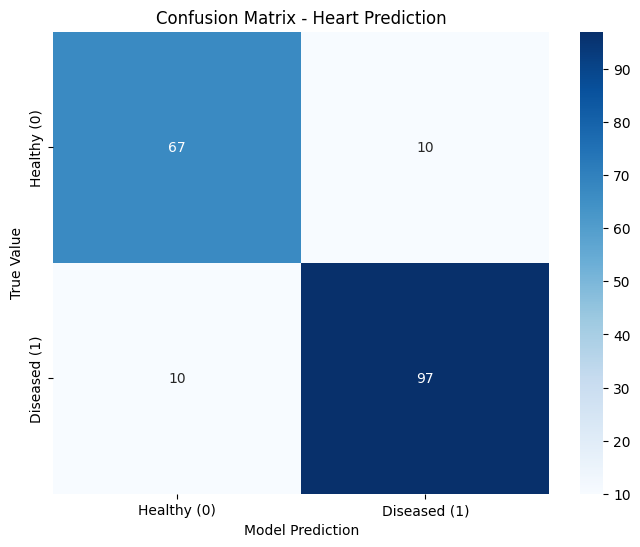

In [20]:
from sklearn.metrics import confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Make predictions with the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 2. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Diseased (1)'],
            yticklabels=['Healthy (0)', 'Diseased (1)'])
plt.title('Confusion Matrix - Heart Prediction')
plt.xlabel('Model Prediction')
plt.ylabel('True Value')
plt.show()


In [16]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        77
           1       0.91      0.91      0.91       107

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



### Conclusion

We can observe an effective model from the data, only 20 of 184 where catagorized incorrectly. Meaning it predicted with a 89% certainty. We can see a clear model where ont he three metrics of Precision, Recall and F1-score it has a minimum effectiveness of 87%.

However, while it is more probable that it will be correct, it is not only far from perfect but also far from being reccomended to be used on an actual medical scenario, it is uncertain enough where it can't be trusted, making this a model for educational purposes only and not reccomended to be used on an actual patient.